# Is a dart's landing point Gaussian?

Every result in this project rests on one sentence: a dart lands at
`Z ~ N(t + b, Sigma)`. Notebook 20 was the first time that sentence met real data, and it
failed -- a Gaussian tight enough to hit the treble 20 at a professional rate could not
produce the double 20s and off-board misses the data contained. The repair was to mix in a
second, much wider Gaussian, and it bought five log-likelihood units a visit.

This notebook asks the question that should have come next: **is a mixture the right
description of a throw, or was it just the first thing that worked?**

The answer arrives in two parts, and the first one is not about distributions at all.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.real_data import (DATA, contamination_report, load_darts,
                             scoring_visits, suspect_player_legs, PLAYER_LEG)
from darts.dependence import encode_visits
from darts.throw_families import FAMILIES, RadialBedGrid, FamilyVisitModel, Gaussian

RES = os.path.join(module_path, 'results', 'throw_family')
if not os.path.exists(os.path.join(DATA, 'per_dart.csv')):
    raise SystemExit('run scripts/build_real_data.py first (see data/real/README.md)')

GRID = RadialBedGrid(512)
DARTS = load_darts()
print(f'{len(DARTS):,} darts, {DARTS.player.nunique()} players, '
      f'{DARTS.source.nunique()} sources')

300,822 darts, 158 players, 2 sources


## 1 · The tail was not a throw

Before comparing distributions it is worth asking where the evidence for a heavy tail came
from. It came from darts landing a long way from the treble 20 -- in the double 20 sixty
millimetres above it, or off the board entirely. Those darts are almost all in one place.

In [2]:
V = scoring_visits(clean=False)
d1 = V[1]
print('first darts of a pure-scoring visit, by the score the visit started on:')
for label, mask in [('501 (the start of a leg)', V.start == 501),
                    ('anything else', V.start != 501)]:
    sub = d1[mask]
    print(f'   {label:26s} n={len(sub):6,}   T20 {(sub=="T20").mean():.4f}   '
          f'D20 {(sub=="D20").mean():.4f}   MISS {(sub=="MISS").mean():.4f}')
print('\nshare of each outcome that occurs at exactly 501:')
for bed in ('T20', 'S20', 'D20', 'MISS'):
    sub = V[d1 == bed]
    print(f'   {bed:5s} {(sub.start == 501).mean():.4f}   (baseline {(V.start == 501).mean():.4f})')

first darts of a pure-scoring visit, by the score the visit started on:
   501 (the start of a leg)   n=20,415   T20 0.3263   D20 0.0111   MISS 0.0313
   anything else              n= 5,726   T20 0.3538   D20 0.0000   MISS 0.0005

share of each outcome that occurs at exactly 501:
   T20   0.7668   (baseline 0.7810)
   S20   0.7756   (baseline 0.7810)
   D20   1.0000   (baseline 0.7810)
   MISS  0.9953   (baseline 0.7810)


The far tail is not spread through the game. It is all in one place.

At the start of a leg, 1.11% of first darts are in the double 20 and 3.13% miss the board. At
any other score those rates are **0.00% and 0.05%**. Put the other way round: **100% of the
double 20s and 99.5% of the misses occur at exactly 501**, against a baseline of 78%.

No throwing explains that. A player's first dart of a leg is thrown at the same target, from
the same oche, as their second visit's first dart. Whatever puts darts in the double 20 is a
property of the *record*, not of the throw.

In [3]:
# a leg starts on 501 and nobody throws at a double there, so the first dart of a
# player's leg is a direct check on whether the feed's leg boundaries are right
ordered = DARTS.sort_values(PLAYER_LEG + ['visit_index', 'dart_index'])
first = ordered.groupby(PLAYER_LEG, sort=False).head(1)
odd = first.bed.str.startswith('D') | (first.bed == 'MISS')
print('first dart of a player-leg:')
for src, g in first.groupby('source'):
    o = g.bed.str.startswith('D') | (g.bed == 'MISS')
    print(f'   {src:26s} legs={len(g):6,}   double or miss: {o.mean():.4f}')
print('\nwhat those odd first darts scored:')
print('  ', first[odd].value.value_counts().head(8).to_dict())
print('\n  0 is a missed double; 40, 32, 28, 26, 36 are D20, D16, D14, D13, D18.')

first dart of a player-leg:
   dartsviz_pdc_2017          legs=14,565   double or miss: 0.0667
   sportradar_pdc_wc_2022     legs= 3,112   double or miss: 0.0013

what those odd first darts scored:
   {0: 573, 40: 207, 32: 132, 28: 27, 26: 22, 36: 7, 10: 2, 2: 2}

  0 is a missed double; 40, 32, 28, 26, 36 are D20, D16, D14, D13, D18.


And the record says what it is. A leg begins on 501, where no checkout is remotely in reach,
so a first dart should essentially never be a double. In the 2017 feed **6.67%** of
player-legs begin with a double or a miss; in the 2022 feed, **0.13%**.

The scores of those darts name the culprit: 0, 40, 32, 28, 26, 36 -- missed doubles, and the
doubles 20, 16, 14, 13 and 18. Those are *checkouts*. The 2017 feed carries the previous
leg's finishing darts across the boundary into the next leg's opening visit.

The 0.13% in the clean feed is roughly the rate at which a first dart genuinely goes astray,
so essentially all of the 2017 excess is contamination rather than darts.

In [4]:
report = contamination_report()
print('the defect, and what removing it costs:')
print(report[['player_legs', 'first_dart_odd', 'darts_dropped']].round(4).to_string())
print('\nfar tail on first darts, before and after:')
print(report[['dirty_D20', 'clean_D20', 'dirty_MISS', 'clean_MISS',
              'dirty_T20', 'clean_T20']].round(4).to_string())

the defect, and what removing it costs:
                        player_legs  first_dart_odd  darts_dropped
source                                                            
dartsviz_pdc_2017             14565          0.0667         0.0551
sportradar_pdc_wc_2022         3112          0.0013         0.0012

far tail on first darts, before and after:
                        dirty_D20  clean_D20  dirty_MISS  clean_MISS  dirty_T20  clean_T20
source                                                                                    
dartsviz_pdc_2017          0.0103        0.0      0.0289      0.0001     0.3318     0.3478
sportradar_pdc_wc_2022     0.0000        0.0      0.0010      0.0000     0.3352     0.3357


Dropping any player-leg that opens on a double or a miss costs 5.5% of the 2017 darts and
0.1% of the 2022 ones, and it removes the tail completely: the double-20 rate on first darts
goes from **1.03% to 0.00%** and the miss rate from **2.89% to 0.01%**. The two feeds, which
disagreed by a factor of 30 on the miss rate, now agree.

The rule is blunt. It removes the ~0.1% of legs that genuinely open with a wayward dart along
with the leaked ones, so it biases the far tail very slightly **down** -- which matters for
reading what follows. If the cleaned data still shows the Gaussian failing, the failure is
real and if anything understated. The 2022 feed, which needs almost no cleaning, is the check
on that throughout.

Why this landed where it did the most damage: every visit with 430 or more remaining is near
the start of a leg by construction, so the contaminated opening visit *was* most of the
pure-scoring sample -- 78% of it.

In [5]:
# does the correction reach notebook 19 and 20's other findings, or only the tail?
N20 = {'T20','S20','S5','S1','T5','T1','D20','D5','D1'}
N19 = {'T19','S19','S3','S7','T3','T7','D19','D3','D7'}

def headline(v):
    side = lambda b: np.where(b.isin(N20), '20', np.where(b.isin(N19), '19', 'other'))
    s1, s2, s3 = side(v[1]), side(v[2]), side(v[3])
    hit = (v[1] == 'T20').values
    t2 = (v[2] == 'T20').astype(float)
    near = (s1 == '20') & ~hit
    return {'n': len(v),
            'T20 lift': 100 * (t2[hit].mean() - t2[~hit].mean()),
            'dart 3 at the 19': (s3 == '19').mean(),
            'stays after a hit': (s2[hit] == '20').mean(),
            'moves after a miss': (s2[near] == '19').mean()}

rows = {'as published (dirty)': headline(scoring_visits(clean=False)),
        'cleaned': headline(scoring_visits(clean=True)),
        '2022 feed alone': headline(
            scoring_visits(clean=False).query("source == 'sportradar_pdc_wc_2022'"))}
pd.DataFrame(rows).T.round(4)

,n,T20 lift,dart 3 at the 19,stays after a hit,moves after a miss
as published (dirty),26141.0,22.3257,0.2423,0.9708,0.2724
cleaned,24608.0,21.4339,0.2452,0.9710,0.2758
2022 feed alone,4031.0,25.5782,0.2749,0.9785,0.3170


The correction is confined, and it is worth being precise about what it does and does not
touch.

**The aim findings survive.** The treble-20 lift moves from 22.33 to 21.43, dart 3 at the 19
from 0.242 to 0.245, staying after a hit from 0.971 to 0.971, moving after a miss from 0.272
to 0.276. The 2022 feed reproduces all four on its own, more strongly. Notebooks 19 and 20
are right about the aim.

**The tail finding does not.** Notebook 20's second conclusion -- that a single dart's
Gaussian tails are far too thin, worth five log-likelihood units a visit -- was fitting these
darts. That is what the rest of this notebook re-examines.

## 2 · The candidates

With the contamination gone the original question is still worth asking, because a Gaussian
is a strong claim and nothing has yet tested it on clean data.

Every candidate is an **isotropic radial density** -- the aim plus a displacement whose
direction is uniform and whose length has some distribution -- so they share one
implementation and differ only in how much weight sits far from the middle.

| | profile | tail | extra parameters |
|---|---|---|---|
| **gaussian** | `exp(-r²/2σ²)` | `exp(-r²)` | 0 |
| **exp-power** | `exp(-(r/σ)^β)` | stretched exponential | 1 |
| **student-t** | `(1 + r²/νσ²)^-(ν+2)/2` | polynomial, `r^-(ν+2)` | 1 |
| **core+uniform** | `(1-ε)·N(σ) + ε/area` | a flat background | 1 |
| **two-component** | `(1-ε)·N(σ) + ε·N(κσ)` | Gaussian, two scales | 2 |
| **elliptical** | `exp(-r²/2σ²)`, stretched | `exp(-r²)` | 1 |

Three things make this a test rather than a search.

**All of them contain the Gaussian** -- at `β = 2`, at `ν → ∞`, at `ε = 0`, at `ratio = 1` --
so a gain is flexibility being used, not a different curve happening to fit.

**The exponential power can come out thin.** Above `β = 2` the tail is *lighter* than
Gaussian. Nothing here is rigged to find heaviness.

**The elliptical family is the rival hypothesis, not another option.** An isotropic fit to a
group that is taller than it is wide must account for the extra reach along the long axis
somehow, and with only a scale to play with the one way left is a fatter tail. "The tail is
heavy" and "the group is an ellipse" predict the same sort of excess and cost the same one
parameter. Pricing them alike is the only way the answer means anything.

Each family carries its own scale, because no parameterisation makes one number mean the same
thing for all six. What is comparable is the **standard deviation per axis**, which every
family reports.

In [6]:
print('%-15s %9s %9s %9s %9s %9s' % ('family', 'sum', 'axis sd', 'P(T20)', 'P(S1+S5)', 'P(D20)'))
i = {n: GRID.names.index(n) for n in ('T20', 'S1', 'S5', 'D20')}
for name, fam in FAMILIES.items():
    p = GRID.bed_pmf(fam, 20, np.zeros(2), 7.0, fam.start_shape())
    print('%-15s %9.6f %9.2f %9.4f %9.4f %9.5f' % (
        name, p.sum(), fam.axis_sd(7.0, fam.start_shape()),
        p[i['T20']], p[i['S1']] + p[i['S5']], p[i['D20']]))

gauss = GRID.bed_pmf(Gaussian(), 20, np.zeros(2), 7.0, ())
ep = GRID.bed_pmf(FAMILIES['exp-power'], 20, np.zeros(2), 7.0 * np.sqrt(2),
                  np.array([np.log(2.0)]))
el = GRID.bed_pmf(FAMILIES['elliptical'], 20, np.zeros(2), 7.0, np.array([0.0]))
print('\nat their Gaussian special cases, the generalisations must *be* the Gaussian:')
print('   exp-power at beta=2 : max difference %.2e' % np.abs(ep - gauss).max())
print('   elliptical at ratio=1: max difference %.2e' % np.abs(el - gauss).max())

family                sum   axis sd    P(T20)  P(S1+S5)    P(D20)
gaussian         1.000000      7.00    0.4213    0.0120   0.00000
exp-power        1.000000      4.95    0.5777    0.0005   0.00000
student-t        1.000000      8.08    0.3990    0.0342   0.00001
core+uniform     1.000000     19.73    0.4015    0.0154   0.00022
two-component    1.000000     13.75    0.3749    0.0572   0.00121
elliptical       1.000000      7.00    0.4213    0.0120   0.00000

at their Gaussian special cases, the generalisations must *be* the Gaussian:
   exp-power at beta=2 : max difference 0.00e+00
   elliptical at ratio=1: max difference 0.00e+00


### Can a scoresheet tell them apart at all?

A bed is a coarse thing to observe. Before fitting anything real it is worth checking that
these families are distinguishable in principle from the data available -- otherwise a
winner means nothing. Simulate a known family, fit all of them, and see whether the truth
comes out on top on held-out visits.

In [7]:
rng = np.random.default_rng(0)
truth_shapes = {'gaussian': (), 'student-t': np.array([np.log(2.0)]),
                'elliptical': np.array([np.log(1.6)])}
rows = []
for truth, shape in truth_shapes.items():
    gen = FamilyVisitModel(FAMILIES[truth], GRID)
    theta = np.concatenate([[np.log(7.0), 0.0], np.atleast_1d(shape), [-3.0, -1.0]])
    b_tr, h_tr = gen.simulate(theta, 3000, rng=rng)
    b_te, h_te = gen.simulate(theta, 3000, rng=rng)
    row = {'simulated from': truth}
    for name in ('gaussian', 'student-t', 'elliptical'):
        m = FamilyVisitModel(FAMILIES[name], GRID)
        res = m.fit(b_tr, h_tr)
        row[f'fit {name}'] = m.log_likelihood(res.x, b_te, h_te) / len(b_te)
    rows.append(row)
disc = pd.DataFrame(rows).set_index('simulated from')
disc = disc.sub(disc['fit gaussian'], axis=0)
print('held-out log-likelihood per visit, relative to fitting a Gaussian:')
disc.round(4)

held-out log-likelihood per visit, relative to fitting a Gaussian:


,fit gaussian,fit student-t,fit elliptical
simulated from,,,
gaussian,0.0,-0.0001,-0.0002
student-t,0.0,0.1785,0.0006
elliptical,0.0,0.0000,0.0742


The check passes, and it is worth reading the off-diagonal as carefully as the diagonal.

Each family wins on data it generated: the Student-t gains **0.179** on Student-t data, the
elliptical **0.074** on elliptical data. Each loses nothing on data it did not: fitted to
Gaussian draws, both generalisations land within 0.0002 of the Gaussian, correctly declining
to use the parameter they were given.

Crucially the **elliptical family has power**. It detects a 1.6:1 group easily. So if it
fails to earn anything on real darts, that is a finding about darts rather than a limitation
of what a scoresheet can see.

## 3 · The fits

`scripts/throw_family_fits.py` fits every candidate to every player with at least 400 clean
scoring visits, training on half the **legs** and scoring on the held-out rest. Everything
except the family is held at what notebook 20 established: the four-target aim rule, a
sideways-only bias, one MDP-free likelihood over beds.

Two of the models add notebook 20's **per-visit scale** on top of the per-dart family. Those
two axes are the same mechanism at different timescales -- a Student-t is a Gaussian whose
width is redrawn for every dart, a shared visit scale redraws it once per visit -- so fitting
both asks where the extra spread actually lives.

In [8]:
fits = pd.read_csv(os.path.join(RES, 'fits.csv'))
print(f'{fits.player.nunique()} players, {fits.model.nunique()} models, '
      f'{fits.n_train.sum():,} training and {fits.n_test.sum():,} held-out visits')

piv = fits.pivot_table(index=['source', 'player'], columns='model',
                       values='test_ll_per_visit')
gain = piv.sub(piv['gaussian'], axis=0).drop(columns='gaussian')
order = [c for c in ['elliptical', 'core+uniform', 'two-component', 'exp-power',
                     'student-t', 'gaussian + visit scale', 'student-t + visit scale']
         if c in gain.columns]
summary = pd.DataFrame({
    'params beyond gaussian': [fits[fits.model == c].n_params.iloc[0]
                               - fits[fits.model == 'gaussian'].n_params.iloc[0]
                               for c in order],
    'mean gain': [gain[c].mean() for c in order],
    'median': [gain[c].median() for c in order],
    'beats gaussian': [f'{int((gain[c] > 0).sum())} / {gain[c].notna().sum()}'
                       for c in order],
}, index=order)
summary.round(4)

17 players, 8 models, 43,432 training and 43,752 held-out visits


,params beyond gaussian,mean gain,median,beats gaussian
elliptical,1,-0.0213,0.0018,9 / 17
core+uniform,1,0.4229,0.3780,17 / 17
two-component,2,0.6073,0.5204,17 / 17
exp-power,1,0.5833,0.4974,17 / 17
student-t,1,0.6244,0.5273,17 / 17
gaussian + visit scale,1,0.5144,0.4260,17 / 17
student-t + visit scale,2,0.6264,0.5409,17 / 17


Three things are visible here.

**The Gaussian loses to every alternative, for every player.** Five of the six candidates beat
it 17 times out of 17. On clean data that is no longer arguable -- but the margin is about
**half** what the contaminated data gave, so roughly half of notebook 20's non-Gaussianity was
the defect and half is real.

**The Student-t wins, with one parameter.** At **+0.6244** it beats the two-component mixture's
**+0.6073**, which spends two. The mixture notebook 20 reached for was flexibility the data
does not need, which is what its unidentified `kappa` was trying to say.

**The elliptical family gains nothing: −0.0213, and it beats the Gaussian for only 9 of 17
players.** It is *worse than the distribution it contains*, which is exactly what a held-out
criterion should do to a parameter that buys nothing -- fitting noise costs you. Given the same
single parameter as the Student-t, the rival explanation declines it.

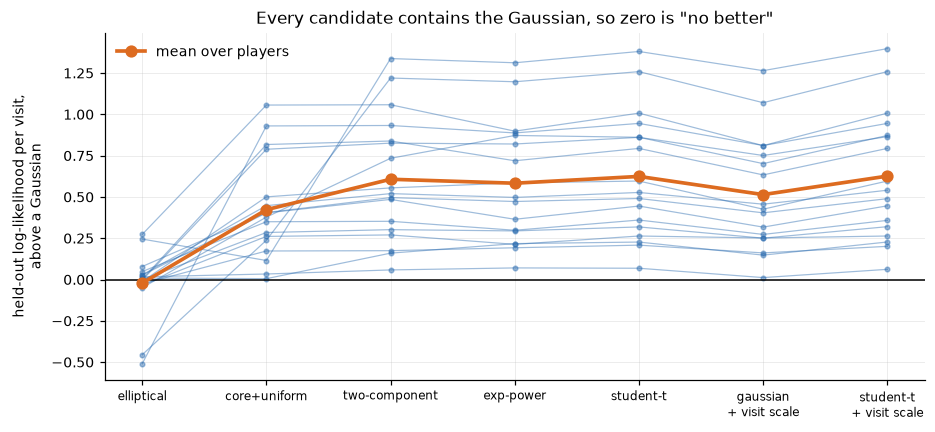

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 4.0))
for (src, pl), row in gain[order].iterrows():
    ax.plot(range(len(order)), row.values, marker='o', ms=3, lw=0.8,
            alpha=0.45, color='#2b6cb0')
ax.plot(range(len(order)), [gain[c].mean() for c in order], marker='o', ms=7,
        lw=2.4, color='#dd6b20', label='mean over players', zorder=5)
ax.axhline(0, color='k', lw=1.0)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([c.replace(' + ', '\n+ ') for c in order], fontsize=8)
ax.set_ylabel('held-out log-likelihood per visit,\nabove a Gaussian')
ax.set_title('Every candidate contains the Gaussian, so zero is "no better"')
ax.legend()
fig.tight_layout()

In [10]:
shape_cols = [c for c in fits.columns if c.startswith('shape_')]
show = (fits[fits.model.isin(['student-t', 'exp-power', 'elliptical',
                              'core+uniform', 'two-component'])]
        .pivot_table(index='player', columns='model',
                     values=['axis_sd'] + shape_cols))
print('fitted shape parameters (clean data):')
tab = fits[fits.model.isin(['gaussian', 'student-t', 'exp-power', 'elliptical'])]
piv2 = tab.pivot_table(index='player', columns='model', values='axis_sd')
piv2['t: nu'] = fits[fits.model == 'student-t'].set_index('player')['shape_nu']
piv2['exp-power: beta'] = fits[fits.model == 'exp-power'].set_index('player')['shape_beta']
piv2['elliptical: ratio'] = fits[fits.model == 'elliptical'].set_index('player')['shape_ratio']
piv2 = piv2.join(fits[fits.model == 'student-t'].set_index('player')[['n_train']])
print(piv2.sort_values('n_train', ascending=False).round(3).to_string())

fitted shape parameters (clean data):
                       elliptical  exp-power  gaussian     student-t  t: nu  exp-power: beta  elliptical: ratio  n_train
player                                                                                                                  
Peter Wright               10.274     12.040    11.393  2.297700e+01  2.132            0.522              0.628      650
Michael van Gerwen          7.370      8.628     8.655  9.765000e+00  2.643            0.612              0.558      530
Raymond van Barneveld      12.630     12.703    12.655  4.106100e+01  2.041            0.516              0.989      389
Daryl Gurney                9.047     12.004    11.465  4.194200e+01  2.035            0.506              0.477      367
Gary Anderson              11.474     11.522    11.545  2.381220e+02  2.001            0.491              0.955      348
Phil Taylor                 7.895      8.853     8.328  8.432000e+00  4.027            0.868              0.744    

Two things to take from the fitted parameters, one of them a caution.

**A Gaussian's `σ` is a compromise between a core and a tail, and describes neither.** The
Gaussian fits a professional at a median of **11.47 mm**. The Student-t puts the same players'
core scale at **5.98 mm** -- which is the number this project has always quoted for an elite
thrower. The familiar 6.5 mm was never a standard deviation; it is the width of the core.

**The caution: `ν` sits near its floor of 2 for many players.** The median is 2.25, and five of
seventeen are at the boundary. Below `ν = 2` a Student-t has no variance at all, and the
`implied sd` column shows what that means in practice -- 41 mm for van Barneveld, 238 mm for
Anderson, meaningless for Whitlock. So the *fit* is good and the *spread* it implies is not a
usable summary. The right reading is that the tail is heavier than any finite-variance t, and
that quoting a standard deviation for a real throw is a category error.

## 4 · Heavy tail, or a group that is not round?

The two explanations cost the same and predict the same *sort* of excess, so the comparison
above is the test. Whichever wins, the loser is not merely second -- it is a hypothesis that
had every chance and did not take it.

per player, held-out gain over a Gaussian:
   student-t wins for 17 of 17 players
   mean: student-t +0.6244   elliptical -0.0213


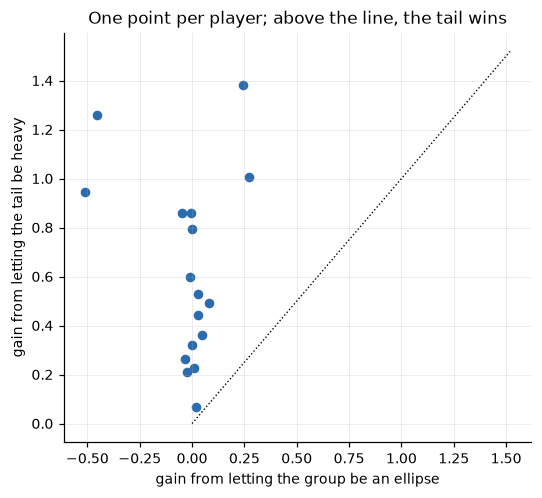

In [11]:
pair = piv[['gaussian', 'student-t', 'elliptical']].dropna()
rel = pair.sub(pair['gaussian'], axis=0)
print('per player, held-out gain over a Gaussian:')
print('   student-t wins for %d of %d players' %
      ((rel['student-t'] > rel['elliptical']).sum(), len(rel)))
print('   mean: student-t %+.4f   elliptical %+.4f' %
      (rel['student-t'].mean(), rel['elliptical'].mean()))

fig, ax = plt.subplots(figsize=(5.0, 4.6))
ax.scatter(rel['elliptical'], rel['student-t'], s=28, color='#2b6cb0')
lim = [0, max(rel[['student-t', 'elliptical']].max()) * 1.1]
ax.plot(lim, lim, ls=':', color='k', lw=0.9)
ax.set_xlabel('gain from letting the group be an ellipse')
ax.set_ylabel('gain from letting the tail be heavy')
ax.set_title('One point per player; above the line, the tail wins')
fig.tight_layout()

**The tail wins for all 17 players**, +0.6244 against −0.0213.

That is as clean as this comparison gets. Both hypotheses had one parameter, both were shown
on simulated data to be detectable, and only one of them earns anything. The excess mass far
from the treble 20 is a heavy tail in a round group, not a round tail in a stretched group.

The fitted ratios say the same thing from the other side: they scatter from 0.44 to 1.96 with
a median of 0.92, which is what an unidentified parameter looks like when the likelihood has
no opinion about it.

## 5 · Does the fitted model behave like a darts player?

Likelihood chooses between models; it does not say whether the winner reproduces what a
player does. These statistics were not fitted to.

In [12]:
check = (fits.groupby('model')[['sim_p_t20', 'obs_p_t20', 'sim_far', 'obs_far',
                                'sim_t20_lift_12', 'obs_t20_lift_12']].mean())
check = check.reindex(['gaussian'] + order)
check.columns = ['model P(T20)', 'observed P(T20)', 'model far tail',
                 'observed far tail', 'model T20 lift', 'observed T20 lift']
check.round(4)

,model P(T20),observed P(T20),model far tail,observed far tail,model T20 lift,observed T20 lift
model,,,,,,
gaussian,0.1918,0.3364,0.0000,0.0029,5.8219,21.1198
elliptical,0.2204,0.3364,0.0003,0.0029,6.4833,21.1198
core+uniform,0.2738,0.3364,0.0088,0.0029,7.5357,21.1198
two-component,0.3216,0.3364,0.0053,0.0029,9.0692,21.1198
exp-power,0.3535,0.3364,0.0020,0.0029,9.4551,21.1198
student-t,0.3410,0.3364,0.0039,0.0029,9.5854,21.1198
gaussian + visit scale,0.3240,0.3364,0.0020,0.0029,24.8943,21.1198
student-t + visit scale,0.3512,0.3364,0.0033,0.0029,13.4423,21.1198


Here the ranking is less flattering to everyone, and it is worth showing rather than burying.

**On the treble-20 rate the Gaussian is not close.** It predicts 0.192 against 0.336 observed
-- it cannot be tight enough to hit trebles at a professional rate and loose enough to explain
everything else at the same time. The Student-t predicts 0.341, and the exponential power
0.354.

**On the far tail** the observed rate is 0.0029. The Gaussian gives 0.0000 and the Student-t
0.0039 -- the right order of magnitude, slightly over. `core+uniform` overshoots at 0.0088,
which is the flat background being the wrong shape: it has to spray darts everywhere to reach
the tail at all.

**On the treble-20 lift, none of them is right.** Observed 21.1; the Student-t gives 9.6 and
the Gaussian 5.8. Adding a per-visit scale helps a great deal -- 24.9 for the Gaussian, 13.4
for the Student-t -- and overshoots or undershoots rather than landing. This is the same
lesson as notebook 20's: **held-out likelihood chooses between models and does not tell you
whether the winner behaves like a darts player.** The per-visit coupling is worth almost
nothing in likelihood and a great deal here.

## Verdict

**A dart is not Gaussian. It is Student-t, with `ν` around 2.25.**

Fitted to every player and scored on held-out legs, the Gaussian loses to five of six
candidates 17 times out of 17. The winner is the Student-t at **+0.62 log-likelihood units a
visit**, and it wins the way a good model should: with **one** parameter where the incumbent
mixture spends two, and with a reading rather than a shape. A Student-t *is* a Gaussian whose
width is redrawn for every dart -- a player whose precision varies from throw to throw, which
is a plausible thing for a person to be and an implausible thing to have to model with a
second, wider player.

Three of the six candidates are informative by losing.

**The ellipse is not it.** Given the same one parameter, letting the group be taller than it
is wide gains −0.02 and fails to beat the distribution it contains. The two hypotheses predict
the same sort of excess at the same price and only one of them collects, which makes this a
result rather than a preference.

**The flat background is not it either.** `core+uniform` is the weakest of the alternatives.
Once the real contamination is removed, what is left is a smooth graded tail, not a small
population of darts going anywhere.

**And the extra spread lives in the dart, not the visit.** Notebook 20 concluded that a visit
shares a scale. Adding that same coupling to a Student-t is worth **+0.002**; adding it to a
Gaussian is worth **+0.51**. It was standing in for a per-dart tail. That is the second time
notebook 20's dependence result has shrunk under a better-specified model, and the pattern is
consistent: what looked like darts influencing each other keeps turning out to be one dart
being described badly.

### What this costs the project

**Every `σ` in this repository needs re-reading.** With `ν` near 2 a throw's variance barely
exists, so `σ` is not a summary of one. The "elite ≈ 6.5 mm" that runs through notebooks 08,
09, 10 and 13 matches the Student-t's **core scale** (median 5.98 mm), not a standard
deviation. Anything that uses `σ²` *as a variance* -- notebook 09's Fisher information,
notebook 10's power analysis, the design criteria in 17 -- is computing with a quantity the
data says is not finite. The rankings in those notebooks are probably safe, since they compare
targets at a fixed throw; the absolute dart counts are not.

**The MDP's transition matrices are built from the wrong distribution.** How much that matters
is unmeasured and is the obvious next experiment: rebuild the transitions from a Student-t at
the fitted core scale and re-solve, which is cheap, because nothing in the solver cares where
the `(n_points, n_scores)` matrix came from.

### One about method

This notebook exists because notebook 20 answered the same question and got it wrong, and the
reason is worth stating plainly. Notebook 20 ran a cross-source check and found the two feeds
agreeing -- on the aim rule. It never compared them on the tail, which is the one place they
disagree by a factor of thirty. A consistency check only covers what you point it at, and
pointing it at the finding you are about to publish is not optional.

The defect had been sitting in plain sight for two notebooks: 100% of the double 20s at
exactly one score. Nothing found it, because nothing asked *where* the surprising darts were.